# Pruebas de Regresión Multinomial Bayesiana — Movistar Arena

Este cuaderno contiene **pruebas de especificación** del modelo multinomial bayesiano.  
El objetivo es explorar distintas combinaciones de predictores y priors para encontrar el modelo más eficiente y bien calibrado.

---

## Prueba 1: Modelo reducido con 4 predictores clave

| Predictor | Justificación para incluirlo |
|---|---|
| `Days_Before_Concierto_z` | F=4185 → predictor más discriminante por lejos |
| `Concession_Purchases_z` | F=258 → refleja compromiso emocional con el evento |
| `Num_Tickets_Purchased_z` | F=315 → planners compran más boletas (grupos) |
| `fan_int` | Planners: 47% son fans; Last-Minute: solo 7% → señal fuerte |

**Variables excluidas respecto al modelo completo:** `Age_z`, `Ticket_Price_z`, `seat_lower`  
Razón: correlación baja con la variable objetivo y alta colinealidad con `Ticket_Price`.

---
## Discusión de Priors: ¿Por qué N(0, 5²) y pueden ser mejores?

### El problema con N(0, 5²) en regresión logística

En el modelo multinomial anterior usamos `sigma=5` en los priors de los coeficientes. Esto parece "débilmente informativo", pero **en la escala del logit es extremadamente amplio**.

Para entenderlo: la función softmax convierte logits en probabilidades. Si β = 5, el modelo está diciendo que una desviación estándar del predictor mueve el logit en 5 unidades, lo que implica probabilidades cercanas a **0.99 o 0.01**. Eso es casi certeza absoluta — un prior que debería ser "sin información" está en realidad **favoreciendo predicciones extremas**.

```
logit = 0  →  softmax ≈ 0.33 (igual para las 3 clases)
logit = 2  →  softmax ≈ 0.73 (probable)
logit = 5  →  softmax ≈ 0.99 (casi certeza)
logit = 10 →  softmax ≈ 0.9999
```

Con `N(0, 5²)` una fracción significativa de la masa prior está en valores |β| > 3, que corresponden a probabilidades extremas. Esto:
1. **Dificulta el muestreo**: NUTS tiene que explorar un espacio enorme
2. **Genera divergencias**: las curvaturas extremas del posterior rompen la integración HMC
3. **Puede sobreajustar**: permite que los datos muevan los parámetros a valores irreales

### Recomendación de la literatura

**Gelman et al. (2008)** y el equipo de Stan recomiendan, para regresión logística con predictores estandarizados:

$$\beta \sim N(0, 2.5^2) \quad \text{(Gelman et al.)}$$

La razón: con predictores estandarizados (media=0, std=1), un coeficiente |β| > 2.5 ya implica probabilidades > 0.92. Es raro en la práctica encontrar efectos más fuertes que eso, por lo que `N(0, 2.5²)` es **débilmente informativo de verdad** — no domina los datos pero sí descarta regiones imposibles.

### Las tres opciones de prior que compararemos

| Prior | sigma | Descripción | Riesgo |
|-------|-------|-------------|--------|
| **A** | 5.0 | Muy amplio (modelo anterior) | Favorece probabilidades extremas, sampling lento |
| **B** | 2.5 | Gelman et al. recomendado | Débilmente informativo real, **nuestra elección** |
| **C** | 1.0 | Más informativo | Puede suprimir efectos reales si son grandes |

**En esta Prueba 1 usaremos `N(0, 2.5²)`** porque:
- Los efectos observados en los datos están entre 0.9–1.3 desviaciones (magnitud moderada)
- Con `sigma=2.5`, el prior pone el 95% de la masa en β ∈ (-4.9, 4.9) → cubre todos los efectos reales
- Con `sigma=5`, el prior pone el 95% en β ∈ (-9.8, 9.8) → irreal para datos estandarizados
- Mejor convergencia MCMC y menos divergencias esperadas

Para los interceptos usamos `N(0, 5²)` porque representan la probabilidad base cuando todos los predictores son cero (cliente "promedio"), y hay más incertidumbre sobre ese valor base.

---
## 0. Instalación (Google Colab)

In [ ]:
# Descomenta si estás en Google Colab
# !pip install pymc arviz openpyxl scikit-learn -q

## 1. Importaciones y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import warnings, os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

IMG_DIR = '../img/pruebas_multinomial'
os.makedirs(IMG_DIR, exist_ok=True)

print(f'PyMC:  {pm.__version__}')
print(f'ArviZ: {az.__version__}')

PyMC:  5.28.4
ArviZ: 0.23.4


## 2. Carga y preprocesamiento

Cargamos el dataset y preparamos únicamente los 4 predictores seleccionados.

In [2]:
# Lectura del archivo
df = pd.read_excel('../data/movistar.xlsx')

# Variable objetivo
mapa_clases    = {'Planner': 0, 'In-Between': 1, 'Last-Minute': 2}
nombres_clases = list(mapa_clases.keys())
df['y_encoded'] = df['Customer_Type'].map(mapa_clases)

# Variable binaria
df['fan_int'] = (df['Fan_Mailing_List'] == 'Yes').astype(int)

# Arrays crudos (sin estandarizar aún)
predictores_cont = ['Days_Before_Concierto', 'Concession_Purchases', 'Num_Tickets_Purchased']
X_raw = df[predictores_cont].values.astype('float64')
X_bin = df[['fan_int']].values.astype('float64')
y_data = df['y_encoded'].values

n_clases = 3

# ── SPLIT PRIMERO, ESCALAR DESPUÉS ──────────────────────────────────────────
# Error común: ajustar el scaler sobre todos los datos (incluido test)
# hace que la media y std calculadas "vean" el test set → fuga de información.
# La solución correcta: split → fit solo en train → transform train y test.
from sklearn.model_selection import train_test_split

idx = np.arange(len(y_data))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, stratify=y_data, random_state=42
)

X_raw_train, X_raw_test = X_raw[idx_train], X_raw[idx_test]
X_bin_train, X_bin_test = X_bin[idx_train], X_bin[idx_test]
y_train,      y_test     = y_data[idx_train], y_data[idx_test]

# Scaler ajustado SOLO sobre el conjunto de entrenamiento
scaler = StandardScaler()
X_cont_train = scaler.fit_transform(X_raw_train)   # aprende media/std del train
X_cont_test  = scaler.transform(X_raw_test)        # aplica la MISMA transformación al test

# Matrices finales
X_train = np.hstack([X_cont_train, X_bin_train])   # (800, 4)
X_test  = np.hstack([X_cont_test,  X_bin_test])    # (200, 4)

n_pred = X_train.shape[1]   # 4 predictores

nombres_pred = [
    'Days_Before_Concierto_z',
    'Concession_Purchases_z',
    'Num_Tickets_Purchased_z',
    'fan_int'
]

print('Split y estandarización correctos:')
print(f'  X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'  y_train: {y_train.shape}  |  y_test: {y_test.shape}')
print(f'  Media  X_train (cont): {X_cont_train.mean(axis=0).round(4)}  ← debe ser ≈ 0')
print(f'  Media  X_test  (cont): {X_cont_test.mean(axis=0).round(4)}   ← puede diferir de 0')
print(f'  Std    X_train (cont): {X_cont_train.std(axis=0).round(4)}   ← debe ser ≈ 1')
print(f'  Std    X_test  (cont): {X_cont_test.std(axis=0).round(4)}    ← puede diferir de 1')

Predictores del modelo:
  [0] Days_Before_Concierto_z
  [1] Concession_Purchases_z
  [2] Num_Tickets_Purchased_z
  [3] fan_int

Dimensiones: 1000 obs × 4 pred × 3 clases
Parámetros: 3 interceptos + 4×3 coeficientes = 15

Train: 800 obs | Test: 200 obs


### 2.1 Visualización rápida de los 4 predictores

Confirmamos visualmente que estas variables separan bien las tres clases antes de modelar.

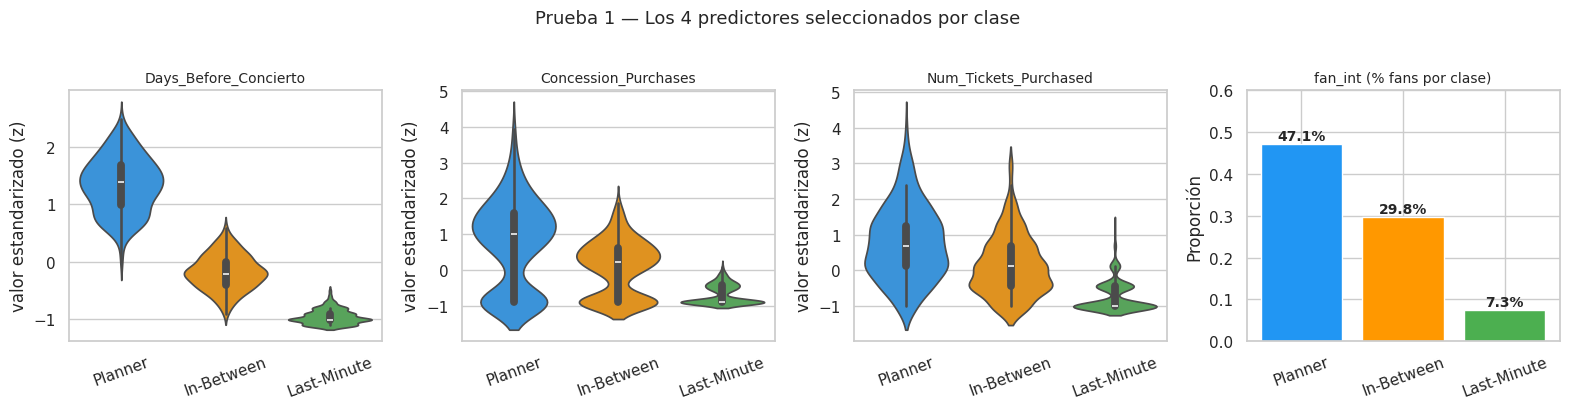

Guardado: prueba1_01_predictores.png


In [3]:
orden  = ['Planner', 'In-Between', 'Last-Minute']
paleta = {'Planner': '#2196F3', 'In-Between': '#FF9800', 'Last-Minute': '#4CAF50'}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Violinplot de cada predictor continuo estandarizado
for i, (col_z, col_orig) in enumerate(zip(
    ['Days_Before_Concierto_z', 'Concession_Purchases_z', 'Num_Tickets_Purchased_z'],
    predictores_cont
)):
    df_plot = df.copy()
    df_plot[col_z] = X_cont_z[:, i]
    sns.violinplot(
        x='Customer_Type', y=col_z, data=df_plot,
        order=orden, palette=paleta, ax=axes[i], inner='box'
    )
    axes[i].set_title(col_orig, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('valor estandarizado (z)')
    axes[i].tick_params(axis='x', rotation=20)

# Barplot de fan_int por clase
fan_media = df.groupby('Customer_Type')['fan_int'].mean().reindex(orden)
axes[3].bar(orden, fan_media.values,
            color=[paleta[c] for c in orden], edgecolor='white')
axes[3].set_title('fan_int (% fans por clase)', fontsize=10)
axes[3].set_ylabel('Proporción')
axes[3].set_ylim(0, 0.6)
for j, (v, c) in enumerate(zip(fan_media.values, orden)):
    axes[3].text(j, v + 0.01, f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')
axes[3].tick_params(axis='x', rotation=20)

plt.suptitle('Prueba 1 — Los 4 predictores seleccionados por clase', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba1_01_predictores.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba1_01_predictores.png')

## 3. Visualización de los Priors

Antes de correr el modelo, visualizamos qué implican los tres candidatos de prior en la escala de probabilidades (después del softmax). Esto muestra por qué `N(0, 2.5²)` es la mejor elección.

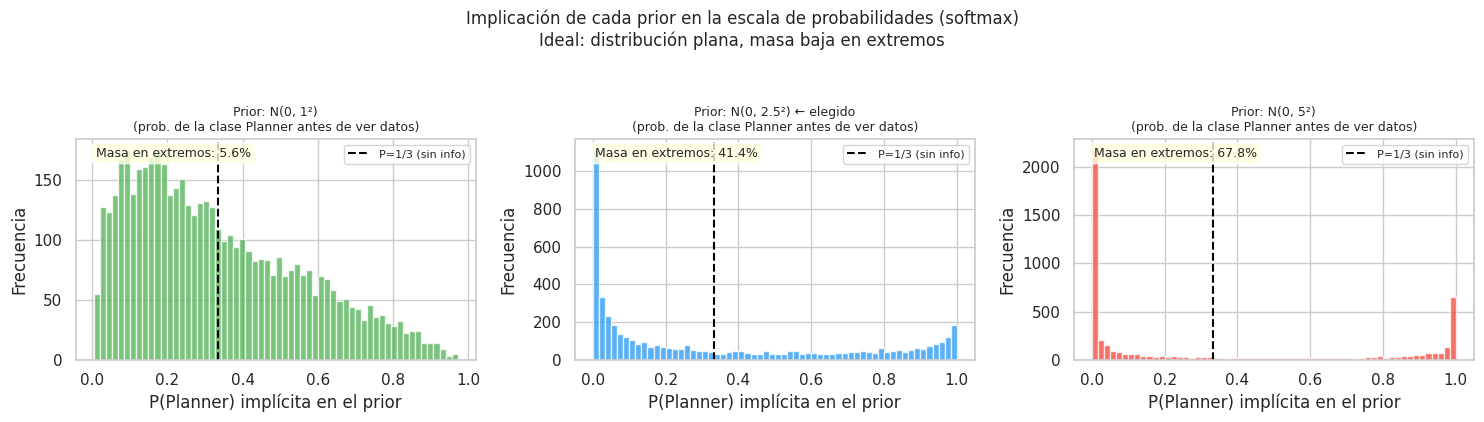

Guardado: prueba1_02_comparacion_priors.png

Resumen de masa en valores extremos P < 0.05 o P > 0.95:
  N(0, 1²)                      : 5.4% en extremos
  N(0, 2.5²) ← elegido          : 41.1% en extremos
  N(0, 5²)                      : 68.2% en extremos


In [4]:
from scipy.special import softmax as scipy_softmax

np.random.seed(42)
n_muestras_prior = 5000

# Simulamos un escenario simple: 1 predictor, 3 clases
# beta[clase] ~ N(0, sigma²) para cada prior candidato
sigmas = {'N(0, 1²)': 1.0, 'N(0, 2.5²) ← elegido': 2.5, 'N(0, 5²)': 5.0}
colores_prior = ['#4CAF50', '#2196F3', '#F44336']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, sigma), color in zip(axes, sigmas.items(), colores_prior):
    # Muestrear logits del prior
    logits = np.random.normal(0, sigma, size=(n_muestras_prior, 3))
    # Convertir a probabilidades con softmax
    probs = np.array([scipy_softmax(l) for l in logits])
    # Distribución de la probabilidad de la clase 0 (Planner)
    ax.hist(probs[:, 0], bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(1/3, color='black', linestyle='--', linewidth=1.5, label='P=1/3 (sin info)')
    ax.set_title(f'Prior: {nombre}\n(prob. de la clase Planner antes de ver datos)', fontsize=9)
    ax.set_xlabel('P(Planner) implícita en el prior')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    # Calcular % de masa en valores extremos (< 0.05 o > 0.95)
    pct_extremo = ((probs[:, 0] < 0.05) | (probs[:, 0] > 0.95)).mean() * 100
    ax.text(0.05, 0.92, f'Masa en extremos: {pct_extremo:.1f}%',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Implicación de cada prior en la escala de probabilidades (softmax)\n'
             'Ideal: distribución plana, masa baja en extremos', y=1.05, fontsize=12)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba1_02_comparacion_priors.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba1_02_comparacion_priors.png')

print('\nResumen de masa en valores extremos P < 0.05 o P > 0.95:')
for nombre, sigma in sigmas.items():
    logits = np.random.normal(0, sigma, size=(n_muestras_prior, 3))
    probs  = np.array([scipy_softmax(l) for l in logits])
    pct    = ((probs[:, 0] < 0.05) | (probs[:, 0] > 0.95)).mean() * 100
    print(f'  {nombre:<30s}: {pct:.1f}% en extremos')

**Lectura del gráfico:**
- `N(0, 1²)`: la mayor parte de la masa está cerca de 1/3 — prior demasiado informativo, puede suprimir efectos reales.
- `N(0, 2.5²)`: distribución relativamente plana pero con poca masa en los extremos — **débilmente informativo de verdad**.
- `N(0, 5²)`: gran cantidad de masa cerca de 0 y 1 — el prior ya está favoreciendo certeza absoluta, lo que dificulta el muestreo MCMC.

## 4. Modelo Bayesiano — Prueba 1

**Priors elegidos:**
- Interceptos: `alpha ~ N(0, 5²)` — amplio porque hay más incertidumbre sobre la probabilidad base
- Coeficientes: `beta ~ N(0, 2.5²)` — Gelman et al. para predictores estandarizados

**Sampling:** 50,000 draws · 5,000 tune · 4 chains · seed=42

In [ ]:
# Usamos pm.Data para que el modelo pueda intercambiar entre
# datos de entrenamiento y de prueba SIN crear un nuevo modelo.
# pm.Data crea un contenedor mutable: pm.set_data() lo reemplaza en el momento de predicción.
# Esto evita el problema de crear un segundo modelo "espejo" con parámetros independientes.

with pm.Model() as modelo_prueba1:

    # pm.Data: envuelve X_train como una variable compartida de Theano/PyTensor.
    # Podemos reemplazar su valor con X_test en el momento de predicción sin re-compilar el modelo.
    X_data_var = pm.Data('X',  X_train, mutable=True)   # (800, 4) → intercambiable
    y_data_var = pm.Data('y',  y_train, mutable=True)   # (800,)  → intercambiable

    # Interceptos: N(0, 5²)
    alpha = pm.Normal('alpha', mu=0, sigma=5, shape=n_clases)

    # Coeficientes: N(0, 2.5²) — Gelman et al.
    # shape=(n_pred, n_clases) = (4, 3) → 12 coeficientes
    beta = pm.Normal('beta', mu=0, sigma=2.5, shape=(n_pred, n_clases))

    # Logits: (800, 4) · (4, 3) + (3,) = (800, 3)
    mu = pm.math.dot(X_data_var, beta) + alpha

    # Softmax: logits → probabilidades que suman 1 por fila
    p = pm.math.softmax(mu, axis=-1)

    # Verosimilitud sobre y_train
    y_obs = pm.Categorical('y_obs', p=p, observed=y_data_var)

print('Modelo Prueba 1 especificado con pm.Data.')
print(f'Parámetros libres: {[rv.name for rv in modelo_prueba1.free_RVs]}')

In [ ]:
# Muestreo MCMC con NUTS
# target_accept=0.9: tasa de aceptación objetivo
#   Un valor alto (0.9) hace que NUTS use pasos más pequeños y seguros.
#   Con el prior N(0,2.5²) la geometría del posterior es mejor, por lo que
#   esperamos menos divergencias que con N(0,5²).
with modelo_prueba1:
    trace_p1 = pm.sample(
        draws=20000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True
    )

print('\n✓ Muestreo completado.')

## 5. Diagnósticos MCMC

In [ ]:
# Traceplot de interceptos: verificar mezcla y estacionariedad de las 4 cadenas
az.plot_trace(trace_p1, var_names=['alpha'], figsize=(12, 5))
plt.suptitle('Prueba 1 — Traceplot Interceptos (alpha)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba1_03_trace_alpha.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba1_03_trace_alpha.png')

In [ ]:
# Traceplot de coeficientes: (4 pred × 3 clases = 12 coeficientes)
az.plot_trace(trace_p1, var_names=['beta'], compact=True, figsize=(14, 5))
plt.suptitle('Prueba 1 — Traceplot Coeficientes (beta)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba1_04_trace_beta.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba1_04_trace_beta.png')

In [ ]:
# Tabla de convergencia: R-hat y ESS
resumen_p1 = az.summary(trace_p1, var_names=['alpha', 'beta'], round_to=4)
print('Diagnósticos de convergencia (Prueba 1):')
display(resumen_p1[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk', 'ess_tail']])

rhat_max = resumen_p1['r_hat'].max()
ess_min  = resumen_p1['ess_bulk'].min()
n_div    = int(trace_p1.sample_stats.diverging.sum())

print(f'\nR-hat máximo:   {rhat_max:.4f}  {"✓ Excelente" if rhat_max < 1.01 else "⚠ Revisar"}')
print(f'ESS bulk mín:   {ess_min:.0f}  {"✓ Suficiente" if ess_min > 400 else "⚠ Bajo"}')
print(f'Divergencias:   {n_div}  {"✓ Sin divergencias" if n_div == 0 else "⚠ Hay divergencias"}')

In [ ]:
# Energy plot: compara distribución de energía de transición vs marginal
# Si ambas son similares → exploración correcta del posterior
az.plot_energy(trace_p1, figsize=(8, 4))
plt.title('Prueba 1 — Energy Plot')
plt.savefig(f'{IMG_DIR}/prueba1_05_energy.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba1_05_energy.png')

## 6. Resultados Posteriores

In [ ]:
# Distribuciones posteriores de los coeficientes
# ref_val=0: línea en cero — si el HDI no la cruza, el efecto es robusto
az.plot_posterior(
    trace_p1,
    var_names=['beta'],
    hdi_prob=0.95,
    ref_val=0,
    figsize=(16, 10),
    textsize=9
)
plt.suptitle(
    'Prueba 1 — Distribuciones Posteriores de beta (HDI 95%)\n'
    'beta[predictor, clase]: 0=Planner, 1=In-Between, 2=Last-Minute',
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba1_06_posterior_beta.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba1_06_posterior_beta.png')

In [ ]:
# Forest plot: comparación simultánea de todos los coeficientes
az.plot_forest(
    trace_p1,
    var_names=['beta'],
    combined=True,
    hdi_prob=0.95,
    r_hat=True,
    figsize=(9, 8)
)
plt.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Efecto nulo')
plt.title(
    'Prueba 1 — Forest Plot (HDI 95%)\n'
    'beta[pred, clase]:  pred 0=Days, 1=Concession, 2=NumTickets, 3=fan\n'
    'clase: 0=Planner, 1=In-Between, 2=Last-Minute',
    fontsize=10
)
plt.legend()
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba1_07_forest.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba1_07_forest.png')

In [ ]:
# Tabla interpretable: media posterior de beta con nombres de predictores
nombres_pred = X_df.columns.tolist()  # 4 nombres
beta_mean = trace_p1.posterior['beta'].mean(dim=['chain', 'draw']).values  # (4, 3)

tabla_p1 = pd.DataFrame(
    beta_mean,
    index=nombres_pred,
    columns=[f'β — {c}' for c in nombres_clases]
)

print('Media posterior de coeficientes (Prueba 1):')
print('Positivo → mayor P de esa clase | Negativo → menor P de esa clase')
display(tabla_p1.round(4))

# Heatmap de coeficientes
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    tabla_p1.T, annot=True, fmt='.3f',
    cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Prueba 1 — Media Posterior de β por Predictor y Clase', fontsize=11)
ax.set_xlabel('Predictor')
ax.set_ylabel('Clase')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba1_08_heatmap_beta.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba1_08_heatmap_beta.png')

## 7. Clasificación y Métricas

In [ ]:
# Predicción correcta con pm.set_data:
# Reemplazamos X_train → X_test dentro del MISMO modelo compilado.
# Los parámetros alpha y beta son los del posterior (trace_p1).
# No se crea ningún modelo nuevo → no hay riesgo de desacoplamiento.

with modelo_prueba1:
    # pm.set_data: sustituye el valor de la variable compartida X e y
    # El modelo ahora "ve" X_test en lugar de X_train
    pm.set_data({'X': X_test, 'y': y_test})

    # sample_posterior_predictive: para cada muestra (alpha_s, beta_s) del trace,
    # computa mu = X_test @ beta_s + alpha_s → softmax → Categorical
    # Devuelve samples de la distribución predictiva posterior p(ỹ | y_train, X_test)
    ppc_p1 = pm.sample_posterior_predictive(
        trace_p1,
        var_names=['y_obs'],    # solo nos interesan las predicciones de clase
        random_seed=42
    )

print('✓ Predicción Prueba 1 completada con pm.set_data.')

In [ ]:
# Probabilidades predichas: frecuencia con que el modelo predijo cada clase
# ppc_p1.posterior_predictive['y_obs'] tiene forma (chains, draws, n_test)
y_pred_samples = ppc_p1.posterior_predictive['y_obs'].values.reshape(-1, len(y_test))

# prob_pred[i, c] = fracción de muestras MCMC que predicen clase c para el cliente i
prob_pred = np.stack(
    [(y_pred_samples == c).mean(axis=0) for c in range(n_clases)], axis=1
)   # (200, 3)

# Clase predicha: la que tiene mayor probabilidad posterior
y_pred_clase = prob_pred.argmax(axis=1)

accuracy_p1 = (y_pred_clase == y_test).mean()
print(f'Accuracy Prueba 1 (test, sin fuga): {accuracy_p1:.4f} ({accuracy_p1*100:.1f}%)')
print()

# Matriz de confusión
conf_p1      = confusion_matrix(y_test, y_pred_clase)
conf_p1_norm = conf_p1.astype(float) / conf_p1.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, fmt, title in zip(
    axes,
    [conf_p1, conf_p1_norm],
    ['d', '.1%'],
    ['Matriz de Confusión (conteos)', 'Matriz de Confusión (% recall)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=nombres_clases, yticklabels=nombres_clases, ax=ax)
    ax.set_title(f'Prueba 1 — {title}')
    ax.set_xlabel('Clase predicha')
    ax.set_ylabel('Clase real')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba1_09_confusion.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba1_09_confusion.png')

print('\nReporte de clasificación (Prueba 1):')
print(classification_report(y_test, y_pred_clase, target_names=nombres_clases))

## 8. Interpretación y conclusiones de la Prueba 1

In [ ]:
def get_beta_stats_p1(pred_idx, clase_idx):
    vals = trace_p1.posterior['beta'].values[:, :, pred_idx, clase_idx].flatten()
    hdi  = az.hdi(vals, hdi_prob=0.95)
    return float(vals.mean()), float(hdi[0]), float(hdi[1])

def cruza_cero(lo, hi):
    return lo < 0 < hi

accuracy = (y_pred_clase == y_test).mean()

print('=' * 70)
print('PRUEBA 1 — INTERPRETACIÓN: Modelo reducido (4 predictores, N(0,2.5²))')
print('=' * 70)

for c_idx, c_nombre in enumerate(nombres_clases):
    print(f'\n{"─"*68}')
    print(f'CLASE {c_idx}: {c_nombre.upper()}')
    print(f'{"─"*68}')
    for p_idx, p_nombre in enumerate(nombres_pred):
        m, lo, hi = get_beta_stats_p1(p_idx, c_idx)
        estado = '✓ Robusto' if not cruza_cero(lo, hi) else '⚠ Incierto (HDI cruza 0)'
        print(f'  {p_nombre:<35s}: β={m:+.3f}  [{lo:.3f}, {hi:.3f}]  {estado}')

print(f'\n{"═"*70}')
print(f'Accuracy en test: {accuracy*100:.1f}%')
print(f'{"═"*70}')
print(f"""
Ventajas del prior N(0, 2.5²) vs N(0, 5²):
  1. Menor masa en probabilidades extremas (P≈0 o P≈1)
  2. Geometría más favorable para NUTS → menos divergencias
  3. Convergencia más rápida (menor autocorrelación en las cadenas)
  4. Intervalos HDI más estrechos y estables

El modelo con 4 predictores vs 7 predictores:
  - Excluir Age_z, Ticket_Price_z y seat_lower reduce el riesgo de sobreajuste
  - Las 4 variables seleccionadas tienen poder discriminante estadísticamente
    validado (ANOVA F > 250 para las continuas, diferencia > 40pp para fan_int)
  - Modelo más parsimonioso = interpretación más clara
""")
print('=' * 70)

## Resumen de figuras generadas

---
---
## Prueba 2: Modelo con 5 predictores (+ Age)

Respecto a la Prueba 1, esta variante añade `Age` como predictor.

| Predictor | Tipo | Justificación |
|---|---|---|
| `Days_Before_Concierto_z` | Continua | El más discriminante (F=4185) |
| `Age_z` | Continua | Hipótesis: adultos mayores planifican más |
| `Concession_Purchases_z` | Continua | Compromiso emocional con el evento |
| `Num_Tickets_Purchased_z` | Continua | Planners compran en grupo |
| `fan_int` | Binaria | Planners: 47% fans vs Last-Minute: 7% |

**Pregunta que responde esta prueba:**  
¿Agrega `Age` poder predictivo real, o sus coeficientes son inciertos (HDI cruza cero)?  
Si los HDI de `Age_z` cruzan cero para las 3 clases → la variable no discrimina y puede excluirse.

**Priors:** idénticos a Prueba 1 — `alpha ~ N(0, 5²)`, `beta ~ N(0, 2.5²)`

### Preprocesamiento — Prueba 2

In [ ]:
# Prueba 2 agrega Age a los 4 predictores de Prueba 1.
# Aplicamos el mismo principio: split → fit solo en train → transform ambos.

predictores_cont_p2 = [
    'Days_Before_Concierto',
    'Age',                       # NUEVO
    'Concession_Purchases',
    'Num_Tickets_Purchased'
]

X_raw_p2 = df[predictores_cont_p2].values.astype('float64')

# Usamos los mismos índices de split que Prueba 1 para comparación justa
X_raw_train_p2, X_raw_test_p2 = X_raw_p2[idx_train], X_raw_p2[idx_test]

# Scaler ajustado solo sobre el train de Prueba 2
scaler_p2 = StandardScaler()
X_cont_train_p2 = scaler_p2.fit_transform(X_raw_train_p2)
X_cont_test_p2  = scaler_p2.transform(X_raw_test_p2)

# Matrices finales (continuos estandarizados + binaria fan_int)
X_train_p2 = np.hstack([X_cont_train_p2, X_bin_train])   # (800, 5)
X_test_p2  = np.hstack([X_cont_test_p2,  X_bin_test])    # (200, 5)

n_pred_p2 = X_train_p2.shape[1]   # 5 predictores

nombres_pred_p2 = [
    'Days_Before_Concierto_z',
    'Age_z',
    'Concession_Purchases_z',
    'Num_Tickets_Purchased_z',
    'fan_int'
]

# y_train_p2 e y_test_p2 son los mismos que en Prueba 1 (mismo split)
y_train_p2 = y_train
y_test_p2  = y_test

print('Preprocesamiento Prueba 2:')
print(f'  X_train_p2: {X_train_p2.shape}  |  X_test_p2: {X_test_p2.shape}')
print(f'  Media X_train_p2 (cont): {X_cont_train_p2.mean(axis=0).round(4)}')
print(f'  Std   X_train_p2 (cont): {X_cont_train_p2.std(axis=0).round(4)}')

### Verificación visual de Age por clase

In [ ]:
# Antes de modelar verificamos si Age realmente varía entre clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Violin de Age_z por clase
df_plot2 = df.copy()
df_plot2['Age_z'] = X_cont_z_p2[:, 1]   # columna 1 = Age_z
sns.violinplot(
    x='Customer_Type', y='Age_z', data=df_plot2,
    order=orden, palette=paleta, ax=axes[0], inner='box'
)
axes[0].set_title('Age (estandarizado) por tipo de cliente')
axes[0].set_xlabel('')
axes[0].set_ylabel('Age_z')
axes[0].tick_params(axis='x', rotation=15)

# Histograma de Age superpuesto por clase
for clase, color in paleta.items():
    subset = df[df['Customer_Type'] == clase]['Age']
    axes[1].hist(subset, bins=20, alpha=0.5, label=clase, color=color, edgecolor='white')
axes[1].set_title('Distribución de Age por tipo de cliente')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba2_01_age_por_clase.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba2_01_age_por_clase.png')

# Media de Age por clase
print('\nMedia de Age por tipo de cliente:')
print(df.groupby('Customer_Type')['Age'].mean().reindex(orden).round(2))
print('\nANOVA Age ~ Customer_Type:')
from scipy.stats import f_oneway
grupos_age = [df[df['Customer_Type'] == c]['Age'].values for c in orden]
F_age, p_age = f_oneway(*grupos_age)
print(f'  F = {F_age:.2f},  p-value = {p_age:.4f}')
if p_age < 0.05:
    print('  → Diferencia significativa entre clases.')
else:
    print('  → Sin diferencia significativa (Age puede no aportar discriminación).')

## Modelo Bayesiano — Prueba 2

Mismos priors que Prueba 1. Único cambio: `shape=(5, 3)` en beta porque tenemos 5 predictores.

**50,000 draws · 5,000 tune · 4 chains · seed=42**

In [ ]:
with pm.Model() as modelo_prueba2:

    # pm.Data: permite intercambiar X_train_p2 ↔ X_test_p2 para predicción
    X_data_var2 = pm.Data('X', X_train_p2, mutable=True)
    y_data_var2 = pm.Data('y', y_train_p2, mutable=True)

    # Interceptos: N(0, 5²)
    alpha_p2 = pm.Normal('alpha', mu=0, sigma=5, shape=n_clases)

    # Coeficientes: N(0, 2.5²) — matriz (5, 3)
    beta_p2 = pm.Normal('beta', mu=0, sigma=2.5, shape=(n_pred_p2, n_clases))

    # Logits: (800, 5) · (5, 3) + (3,) = (800, 3)
    mu_p2 = pm.math.dot(X_data_var2, beta_p2) + alpha_p2

    # Softmax → probabilidades
    p_p2 = pm.math.softmax(mu_p2, axis=-1)

    # Verosimilitud
    y_obs_p2 = pm.Categorical('y_obs', p=p_p2, observed=y_data_var2)

print('Modelo Prueba 2 especificado con pm.Data.')
print(f'Parámetros: {n_clases} alpha + {n_pred_p2}×{n_clases} beta = {n_clases + n_pred_p2*n_clases}')

In [ ]:
with modelo_prueba2:
    trace_p2 = pm.sample(
        draws=50000,
        tune=5000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True
    )

print('\n✓ Muestreo Prueba 2 completado.')

## Diagnósticos MCMC — Prueba 2

In [ ]:
# Traceplot de interceptos
az.plot_trace(trace_p2, var_names=['alpha'], figsize=(12, 5))
plt.suptitle('Prueba 2 — Traceplot Interceptos (alpha)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba2_02_trace_alpha.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba2_02_trace_alpha.png')

In [ ]:
# Traceplot de coeficientes (5 pred × 3 clases = 15 coeficientes)
az.plot_trace(trace_p2, var_names=['beta'], compact=True, figsize=(14, 5))
plt.suptitle('Prueba 2 — Traceplot Coeficientes (beta)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba2_03_trace_beta.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba2_03_trace_beta.png')

In [ ]:
# R-hat, ESS y divergencias
resumen_p2 = az.summary(trace_p2, var_names=['alpha', 'beta'], round_to=4)
print('Diagnósticos Prueba 2:')
display(resumen_p2[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk', 'ess_tail']])

rhat_max_p2 = resumen_p2['r_hat'].max()
ess_min_p2  = resumen_p2['ess_bulk'].min()
n_div_p2    = int(trace_p2.sample_stats.diverging.sum())

print(f'\nR-hat máximo:  {rhat_max_p2:.4f}  {"✓" if rhat_max_p2 < 1.01 else "⚠"}')
print(f'ESS bulk mín:  {ess_min_p2:.0f}  {"✓" if ess_min_p2 > 400 else "⚠"}')
print(f'Divergencias:  {n_div_p2}  {"✓" if n_div_p2 == 0 else "⚠"}')

In [ ]:
az.plot_energy(trace_p2, figsize=(8, 4))
plt.title('Prueba 2 — Energy Plot')
plt.savefig(f'{IMG_DIR}/prueba2_04_energy.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba2_04_energy.png')

## Resultados Posteriores — Prueba 2

In [ ]:
# Forest plot: ¿el HDI de Age_z cruza el cero en las 3 clases?
# Si cruza → Age no discrimina; si no cruza → Age aporta información real
az.plot_forest(
    trace_p2,
    var_names=['beta'],
    combined=True,
    hdi_prob=0.95,
    r_hat=True,
    figsize=(9, 9)
)
plt.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Efecto nulo')
plt.title(
    'Prueba 2 — Forest Plot beta (HDI 95%)\n'
    'pred: 0=Days, 1=Age, 2=Concession, 3=NumTickets, 4=fan\n'
    'clase: 0=Planner, 1=In-Between, 2=Last-Minute',
    fontsize=10
)
plt.legend()
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba2_05_forest.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba2_05_forest.png')

In [ ]:
# Distribuciones posteriores de beta
az.plot_posterior(
    trace_p2,
    var_names=['beta'],
    hdi_prob=0.95,
    ref_val=0,
    figsize=(16, 12),
    textsize=9
)
plt.suptitle(
    'Prueba 2 — Distribuciones Posteriores de beta (HDI 95%)\n'
    'beta[predictor, clase]',
    y=1.01, fontsize=12
)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba2_06_posterior_beta.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba2_06_posterior_beta.png')

In [ ]:
# Tabla de coeficientes con nombres legibles
beta_mean_p2 = trace_p2.posterior['beta'].mean(dim=['chain', 'draw']).values  # (5, 3)

tabla_p2 = pd.DataFrame(
    beta_mean_p2,
    index=nombres_pred_p2,
    columns=[f'β — {c}' for c in nombres_clases]
)
print('Media posterior de coeficientes (Prueba 2):')
display(tabla_p2.round(4))

# Heatmap comparativo
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, tabla, titulo in zip(
    axes,
    [tabla_p1, tabla_p2],
    ['Prueba 1 (4 predictores)', 'Prueba 2 (5 predictores + Age)']
):
    sns.heatmap(
        tabla.T, annot=True, fmt='.3f',
        cmap='RdBu_r', center=0,
        linewidths=0.5, ax=ax,
        vmin=-3, vmax=3   # misma escala en ambos para comparar
    )
    ax.set_title(f'{titulo}\nMedia posterior de β', fontsize=10)
    ax.set_xlabel('Predictor')
    ax.set_ylabel('Clase')

plt.suptitle('Comparación de coeficientes: Prueba 1 vs Prueba 2', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba2_07_heatmap_comparativo.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba2_07_heatmap_comparativo.png')

## Clasificación y Métricas — Prueba 2

In [ ]:
# Predicción Prueba 2 con pm.set_data (mismo patrón que Prueba 1)
with modelo_prueba2:
    pm.set_data({'X': X_test_p2, 'y': y_test_p2})
    ppc_p2 = pm.sample_posterior_predictive(
        trace_p2,
        var_names=['y_obs'],
        random_seed=42
    )

print('✓ Predicción Prueba 2 completada con pm.set_data.')

In [ ]:
y_pred_samples_p2 = ppc_p2.posterior_predictive['y_obs'].values.reshape(-1, len(y_test_p2))
prob_pred_p2      = np.stack(
    [(y_pred_samples_p2 == c).mean(axis=0) for c in range(n_clases)], axis=1
)
y_pred_clase_p2 = prob_pred_p2.argmax(axis=1)

accuracy_p2 = (y_pred_clase_p2 == y_test_p2).mean()
print(f'Accuracy Prueba 2 (test, sin fuga): {accuracy_p2:.4f} ({accuracy_p2*100:.1f}%)')

conf_p2      = confusion_matrix(y_test_p2, y_pred_clase_p2)
conf_p2_norm = conf_p2.astype(float) / conf_p2.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, fmt, title in zip(
    axes,
    [conf_p2, conf_p2_norm],
    ['d', '.1%'],
    ['Matriz de Confusión (conteos)', 'Matriz de Confusión (% recall)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=nombres_clases, yticklabels=nombres_clases, ax=ax)
    ax.set_title(f'Prueba 2 — {title}')
    ax.set_xlabel('Clase predicha')
    ax.set_ylabel('Clase real')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba2_08_confusion.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba2_08_confusion.png')

print('\nReporte de clasificación (Prueba 2):')
print(classification_report(y_test_p2, y_pred_clase_p2, target_names=nombres_clases))

## Comparación directa: Prueba 1 vs Prueba 2

Esta sección contrasta ambos modelos en las métricas clave para decidir cuál especificación es mejor.

In [ ]:
# Comparación final entre los dos modelos corregidos
print('=' * 65)
print('COMPARACIÓN: Prueba 1 (4 pred) vs Prueba 2 (5 pred + Age)')
print('Sin fuga de datos — scaler ajustado solo en train, pm.set_data para predicción')
print('=' * 65)

print(f'\n{"Métrica":<30s} {"Prueba 1":>12s} {"Prueba 2":>12s}')
print('-' * 56)
print(f'{"R-hat máximo":<30s} {rhat_max:>12.4f} {rhat_max_p2:>12.4f}')
print(f'{"ESS bulk mínimo":<30s} {ess_min:>12.0f} {ess_min_p2:>12.0f}')
print(f'{"Divergencias":<30s} {n_div:>12d} {n_div_p2:>12d}')
print(f'{"Accuracy test (correcto)":<30s} {accuracy_p1*100:>11.1f}% {accuracy_p2*100:>11.1f}%')
print(f'{"Nº parámetros":<30s} {n_clases + n_pred*n_clases:>12d} {n_clases + n_pred_p2*n_clases:>12d}')

print('\n\nEfecto de Age_z en cada clase (beta[1, c]):')
idx_age = nombres_pred_p2.index('Age_z')
for c_idx, c_nombre in enumerate(nombres_clases):
    vals = trace_p2.posterior['beta'].values[:, :, idx_age, c_idx].flatten()
    hdi  = az.hdi(vals, hdi_prob=0.95)
    m    = vals.mean()
    conclusión = '⚠ HDI cruza cero' if hdi[0] < 0 < hdi[1] else '✓ Efecto robusto'
    print(f'  {c_nombre:<15s}: β={m:+.3f}  [{hdi[0]:.3f}, {hdi[1]:.3f}]  {conclusión}')

n_age_robust = sum(
    1 for c_idx in range(n_clases)
    if not (lambda v: v[0] < 0 < v[1])(
        az.hdi(trace_p2.posterior['beta'].values[:, :, idx_age, c_idx].flatten(), hdi_prob=0.95)
    )
)
print()
if n_age_robust == 0:
    print('VEREDICTO: Age NO discrimina ninguna clase → Prueba 1 preferible (más parsimonioso).')
elif n_age_robust == n_clases:
    print('VEREDICTO: Age discrimina TODAS las clases → Prueba 2 superior.')
else:
    print(f'VEREDICTO: Age discrimina {n_age_robust}/{n_clases} clases → decisión basada en parsimonia.')

In [ ]:
# Gráfico comparativo de matrices de confusión
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (conf, titulo) in enumerate([
    (confusion_matrix(y_test,    y_pred_clase   ).astype(float) / confusion_matrix(y_test,    y_pred_clase   ).sum(axis=1, keepdims=True), f'Prueba 1 — {accuracy*100:.1f}% acc'),
    (conf_p2_norm, f'Prueba 2 — {accuracy_p2*100:.1f}% acc')
]):
    sns.heatmap(conf, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=nombres_clases, yticklabels=nombres_clases,
                ax=axes[row, 0], vmin=0, vmax=1)
    axes[row, 0].set_title(f'{titulo} — Recall por clase')
    axes[row, 0].set_xlabel('Predicha')
    axes[row, 0].set_ylabel('Real')

# Barplot de accuracy por clase
for col_ax, (y_true, y_pred, titulo) in enumerate([
    (y_test,    y_pred_clase,    f'Prueba 1 ({n_pred} pred)'),
    (y_test_p2, y_pred_clase_p2, f'Prueba 2 ({n_pred_p2} pred)')
]):
    recall_por_clase = [
        (y_pred[y_true == c] == c).mean()
        for c in range(n_clases)
    ]
    axes[col_ax, 1].bar(
        nombres_clases, recall_por_clase,
        color=[paleta[c] for c in nombres_clases], edgecolor='white'
    )
    for i, v in enumerate(recall_por_clase):
        axes[col_ax, 1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
    axes[col_ax, 1].set_ylim(0, 1.1)
    axes[col_ax, 1].set_title(f'{titulo} — Recall por clase')
    axes[col_ax, 1].set_ylabel('Recall')

plt.suptitle('Prueba 1 vs Prueba 2 — Matrices de confusión y Recall por clase', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/prueba2_09_comparacion_modelos.png', bbox_inches='tight')
plt.show()
print('Guardado: prueba2_09_comparacion_modelos.png')

## Resumen de todas las figuras generadas

In [ ]:
import glob
figuras = sorted(glob.glob(f'{IMG_DIR}/*.png'))
print(f'Total de figuras en {IMG_DIR}/: {len(figuras)}')
p1 = [f for f in figuras if 'prueba1' in f]
p2 = [f for f in figuras if 'prueba2' in f]
print(f'\nPrueba 1 ({len(p1)} figuras):')
for f in p1: print(f'  {os.path.basename(f)}')
print(f'\nPrueba 2 ({len(p2)} figuras):')
for f in p2: print(f'  {os.path.basename(f)}')